In [1]:
%load_ext autoreload
%autoreload 2
# Reloads edited .py modules (online_learning_utils, casual_multioutput_pipeline, ...) before every
# cell, so changes to their source take effect without restarting the kernel.

# Online learning — bandit-style duel (UCB & Thompson Sampling)

A variant of the pairwise duel (`02_online_learning_duel`) that swaps the Boltzmann
exploration/exploitation switch (`policy`, in `online_learning_utils`) for two genuine
multi-armed-bandit selection rules, also in `online_learning_utils`:

- **UCB1** (`policy_ucb`): score each arriving patient as `conflict + c * uncertainty` — the
  model's current value estimate plus an exploration bonus proportional to how little the
  model knows about that patient yet — and enrol the higher score.
- **Thompson Sampling** (`policy_thompson`): draw one sample per patient from
  `N(conflict, uncertainty)` — the model's belief about its value and its confidence in that
  belief — and enrol whichever draw is higher.

Both replace `duel_by_angle` entirely: the explore/exploit trade-off now lives inside the score
itself instead of a separate epsilon-schedule that switches between "most uncertain" and "duel
winner". Phase 1 (seed → fit → hyper-tune on the seed, 20 trials) is unchanged from
`02_online_learning_duel`.
Phase 2 runs **both** policies, each against its own matched random baseline, with the same
enrolment RNG seed so the comparison isolates the policy and not the random draws.

Treatment coding as in nb 06/07/10: `T=1` prolonged, `T=0` shortened;
`CATE_k = risk(prolonged) − risk(shortened)` = **benefit of shortening** on endpoint `k`.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')                       # silence LGBM feature-name / small-sample notes

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'data'))
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

Xn = X.select_dtypes(include=[np.number])                                        # numeric design matrix (nb 06)
T  = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()   # 1=prolonged, 0=shortened
ENDPOINTS = {'bleed': 'cec_bleed_335d', 'death': 'cec_cvdeath_335d',
             'mi': 'cec_mi_335d', 'stroke': 'cec_stroke_335d'}
N = len(T)
print('patients:', N, '| prolonged:', int(T.sum()), 'shortened:', int((T == 0).sum()))

patients: 4579 | prolonged: 2284 shortened: 2295


## The online model and the conflict score

Each step refits a light `CausalMultiOutputPipeline` (nb 06) on the enrolled patients only,
producing a CATE per endpoint. The **conflict** pits the bleeding benefit of shortening against
the three ischaemic costs, z-scored so bleeding — the frequent event — does not dominate.
`conflict_from_model` re-scores *every* patient after each refit, and `uncertainty_from_model`
does the same with `predict_cate_std` — both are what `policy_ucb` / `policy_thompson` read. The
forest is kept deliberately small: it is refit after every enrolment, so a few trees plus cheap
first-stage LGBM nuisances and a median imputer keep each step ≈ 1 s.

In [3]:
CF_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'Meta-learning', 'causal_forest'))
sys.path.insert(0, CF_DIR)
from functools import partial
from joblib import Parallel, delayed
from casual_multioutput_pipeline import CausalMultiOutputPipeline, CF_MODEL_PRESETS
from online_learning_utils import (z, make_pipeline, fit_cate, conflict_from_model,
                                    net_benefit_from_model, tune_on_seed, policy_ucb,
                                    policy_thompson, weighted_isch,
                                    DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS)

ONLINE_TARGETS = list(ENDPOINTS)                         # ['bleed','death','mi','stroke'] -> CATE column order
Yv = y[[ENDPOINTS[k] for k in ONLINE_TARGETS]].to_numpy()
BLEED_IDX = ONLINE_TARGETS.index('bleed')                # seed tuning targets the bleeding endpoint (nb 06 convention)
ISCH_WEIGHTS = {'death': 0.2, 'mi': 0.4, 'stroke': 0.4}   # ischaemic weighting for conflict_from_model -- same values components_from_origin reads

# DEFAULT_CF_PARAMS / DEFAULT_NUISANCE_PARAMS are imported above from online_learning_utils:
# the single canonical light default forest shared by nb 02 / 02_bandits / 03 / 04 / 05, so runs
# of different notebooks are comparable by construction. Do NOT redefine them in this cell --
# a local copy shadows the import and silently re-forks the configuration; edit the module.
# The seed hyper-tuning (next section, same objective as
# Meta-learning/causal_forest/run_optuna_tuning.py) can replace them with an AUTOC-tuned config,
# which fit_cate then uses for every refit -- and it is ON (N_TRIALS = 20, seed only), so they
# are the fallback rather than what runs.

def uncertainty_from_model(model):
    """Score EVERY patient with the current online model and rebuild the uncertainty frame
    (same formula as nb 01 / nb 02_duel). effect = risk(prolonged) - risk(shortened) = benefit
    of shortening."""
    cate = model.predict_cate_std(Xn.values)
    df = pd.DataFrame({k: cate[:, ONLINE_TARGETS.index(k)] for k in ENDPOINTS})
    df['uncertainty'] = z(df['bleed']) + weighted_isch({k: z(df[k]) for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)
    return df

## Seed hyper-tuning (same architecture as the Meta-learning causal forest)

Before enrolment starts, the forest fitted on the random seed can optionally be hyper-tuned with
the *same* Optuna objective as the offline causal forest
(`Meta-learning/causal_forest/run_optuna_tuning.py`) — the AUTOC lower bound on the bleeding
endpoint. It runs with `N_TRIALS = 20`, the same budget as `02_online_learning_duel` and nb 03–05,
and it runs **only here**: the seed is the last cohort still drawn at random, so it is the only one
on which the tuning objective targets the population rather than a population the score itself has
built. Nothing is re-tuned once enrolment starts.

## The algorithm

**Phase 1** (`seed_fit_tune`, unchanged from `02_online_learning_duel`): draw a random seed, fit
the forest on it, optionally hyper-tune. The seed patients keep the arm the trial randomised
them to — no model exists yet to choose one.

**Phase 2** (`run_online`): patients arrive **two at a time**; `select` — `policy_ucb` or
`policy_thompson` — scores both with the *current* model's `conflict` (value) and `uncertainty`
(confidence) frames and picks the one to enrol. The winner keeps its **real, trial-randomised**
`(T, Y)` — nothing is imputed or reallocated, so `fit_cate` needs no change. The model is refit
every `REFIT_EVERY` enrolments, so later decisions are made by a model that has learned from
every earlier one. A matched **random** baseline (a coin-flip of the same pair, no refit) grows
alongside the guided cohort so both are read at a common `n`.

Both policies are run from `seed_fit_tune`'s output with the **same `enrol_seed`**, so the
arrival order and the coin-flip baseline draw from identically-seeded randomness — the only thing
that differs between the two runs is the selection rule itself.

In [4]:
def seed_fit_tune(n_seed, seed=0, n_trials=0, tune_cv=3, n_test=0,
                  n_jobs=32, lgbm_n_jobs=16):
    """PHASE 1 — seed, fit, hyper-tune.

    Draw the first `n_seed` RANDOM patients (their real, trial-randomised treatment), fit the
    causal forest on them, then optionally hyper-tune it on that seed with the same Optuna
    objective as the offline causal forest (AUTOC lower bound on the bleeding endpoint). Returns
    the arrival `order`, the seed cohort and the tuned cf_params / nuisance_params.
    """
    rng   = np.random.default_rng(seed)
    order = rng.permutation(N)                       # arrival order over the whole cohort
    stream_end = N - n_test
    test_idx   = list(order[stream_end:])
    seed_idx   = list(order[:n_seed])                # seed = random draw, from the streamable part

    print(f'PHASE 1  seed fit on {n_seed} random patients ...')
    fit_cate(seed_idx, Xn, Yv, T, CausalMultiOutputPipeline, DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS)

    if n_trials:
        print(f'PHASE 1  hyper-tuning on the seed ({n_trials} trials, AUTOC lower bound on bleed) ...')
        # optuna_n_jobs=1: Optuna's n_jobs are GIL-bound threads and each one still spawns
        # its own n_jobs/lgbm_n_jobs workers -> the product oversubscribes the machine.
        cf_params, nuisance_params, study = tune_on_seed(
            seed_idx, Xn, Yv, T, CausalMultiOutputPipeline, CF_MODEL_PRESETS, BLEED_IDX,
            n_trials=n_trials, cv=tune_cv, seed=seed,
            optuna_n_jobs=1, n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs)
        print(f'         best CV score (-AUTOC lower bound) = {study.best_value:+.4f}   '
              f'nuisance_level={study.best_params["nuisance_level"]!r}')
        print(f'         tuned cf_params = {cf_params}')
    else:
        print('PHASE 1  hyper-tuning OFF (N_TRIALS = 0) — running the fixed DEFAULT_CF_PARAMS forest ...')
        cf_params, nuisance_params, study = DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS, None

    pipeline = make_pipeline(CausalMultiOutputPipeline, cf_params, nuisance_params)
    pipeline.fit(Xn.values[seed_idx], Yv[seed_idx], T[seed_idx])
    pred = pipeline.predict_cate(Xn.values[seed_idx])
    print(f'         seed cohort CATE mean = {pred.mean():+.4f}   std = {pred.std():.4f}   '
          f'conflict mean = {conflict_from_model(pipeline, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)["conflict"].iloc[seed_idx].mean():+.4f}')

    return dict(order=order, seed_idx=seed_idx, test_idx=test_idx, stream_end=stream_end,
                cf_params=cf_params, nuisance_params=nuisance_params, study=study)


REFIT_EVERY = 100   # refit (and re-score every patient) this often

In [5]:
def run_online(prep, n_steps, select, enrol_seed=0, *,
               score_fn=conflict_from_model, score_col='conflict',
               n_jobs=32, lgbm_n_jobs=16, verbose=True):
    """PHASE 2 — online enrolment with a pairwise bandit policy.

    Generalises the win-win (`conflict_from_model` / `'conflict'`) and trade-off
    (`net_benefit_from_model` / `'net_benefit'`) regimes -- previously two copy-pasted
    functions (`run_online` / `run_online_net_benefit`) -- into one, parametrised on which
    frame to build (`score_fn`) and which column the duel/history read (`score_col`).
    `select` must already be bound to the same `score_col` (e.g. `functools.partial(policy_ucb,
    score_col='net_benefit')`) so the duel and the history/printing read the same column.

    Continues from `seed_fit_tune`'s output: patients arrive TWO AT A TIME, `select(i, j, rng,
    uncertainty, scores)` -- `policy_ucb` or `policy_thompson` -- keeps the more informative
    one, which is enrolled with its real, trial-randomised `(T, Y)`. Everything enrolled goes
    back into the forest, refit every `REFIT_EVERY` enrolments; the loser is dropped. A matched
    random arm (a coin-flip of the same pair, no refit) grows only when the guided arm does, so
    both are read at a common n. `enrol_seed` seeds a FRESH rng for this call, independent of
    any other `run_online` call, so two policies run against `seed_fit_tune`'s SAME prep with
    the SAME `enrol_seed` see identical randomness.

    `n_jobs`/`lgbm_n_jobs` are forwarded to every `fit_cate` refit inside the loop -- pass
    smaller values when several `run_online` calls run concurrently (see
    `run_policies_parallel` below) so the machine isn't oversubscribed; the defaults (32/16)
    reproduce the previous single-call behaviour exactly.

    Returns a dict; the score frame is stored under its own regime key (`run['conflict']` or
    `run['net_benefit']`, via `**{score_col: scores}`) so callers that only ever used one
    regime keep reading it exactly as before.
    """
    rng        = np.random.default_rng(enrol_seed)
    order      = prep['order']
    cf_params, nuisance_params = prep['cf_params'], prep['nuisance_params']
    enrolled   = list(prep['seed_idx'])
    unenrolled = []
    rnd        = list(prep['seed_idx'])               # baseline cohort (shares the same seed)
    stream_end = prep.get('stream_end', N)
    pos        = len(enrolled)

    model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params, nuisance_params,
                            n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs)
    scores      = score_fn(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
    uncertainty = uncertainty_from_model(model)
    hist = []

    for step in range(n_steps):
        if pos + 1 >= stream_end:
            break

        i, j = int(order[pos]), int(order[pos + 1])
        pos += 2

        w = select(i, j, rng, uncertainty, scores)

        unenrolled.append(j if w == i else i)
        enrolled.append(w)
        rnd.append(i if rng.random() < 0.5 else j)   # baseline: coin-flip between the same pair

        if len(enrolled) % REFIT_EVERY == 0:
            if verbose:
                print(f"step {step + 1}  enrolled {len(enrolled):4d}  "
                    f"{score_col}={scores[score_col].iloc[enrolled].mean():+.3f}")
            # No re-tuning here -- cf_params/nuisance_params stay the phase-1 ones for the
            # whole run (never re-tune mid-loop on a cohort the selection itself constructed).
            model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params, nuisance_params,
                                    n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs)
            scores      = score_fn(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
            uncertainty = uncertainty_from_model(model)

        hist.append(dict(step=step,
                         n=len(enrolled),
                         score_sel=float(scores[score_col].iloc[enrolled].mean()),
                         score_rnd=float(scores[score_col].iloc[rnd].mean())))

    return dict(model=model, enrolled=enrolled, rnd=rnd, hist=pd.DataFrame(hist),
                unenrolled=unenrolled, uncertainty=uncertainty, score_col=score_col,
                **{score_col: scores})


def run_policies_parallel(prep, n_steps, selects, enrol_seed, score_fn, score_col,
                          total_cores=None, verbose_jobs=10):
    """Run one `run_online` per (name, select) pair in `selects` CONCURRENTLY via joblib,
    dividing the machine's cores across the len(selects) simultaneous forest-refitting loops
    so they don't oversubscribe each other's internal n_jobs/lgbm_n_jobs. Returns
    {name: run_dict} in `selects`' insertion order."""
    total_cores = total_cores or os.cpu_count() or 32
    n_parallel      = len(selects)
    fit_n_jobs      = max(total_cores // n_parallel, 4)
    fit_lgbm_n_jobs = max(fit_n_jobs // 2, 2)

    def _one(name, select):
        run = run_online(prep, n_steps, select=select, enrol_seed=enrol_seed,
                         score_fn=score_fn, score_col=score_col,
                         n_jobs=fit_n_jobs, lgbm_n_jobs=fit_lgbm_n_jobs, verbose=False)
        return name, run

    results = Parallel(n_jobs=n_parallel, verbose=verbose_jobs)(
        delayed(_one)(name, select) for name, select in selects.items())
    return dict(results)


def print_run_summary(runs, y):
    """runs: {name: run_dict}. Prints, per policy: enrolled count, final mean score
    (selected vs random -- reads `hist['score_sel']`/`['score_rnd']`, whatever score_col that
    run used), and per-endpoint observed event rates for selected vs random. Replaces the
    near-identical print loops previously duplicated for the win-win and net-benefit runs."""
    for name, run in runs.items():
        sel, rnd, sc, h = run['enrolled'], run['rnd'], run['score_col'], run['hist']
        print(f'{name}  enrolled={len(sel)}   '
              f'mean {sc}  selected={h["score_sel"].iloc[-1]:+.3f}   '
              f'random={h["score_rnd"].iloc[-1]:+.3f}')
        for k in ENDPOINTS:
            yr = y[ENDPOINTS[k]].to_numpy()
            print(f'  event rate {k:7s}  selected={yr[sel].mean():.3f}   '
                  f'random={yr[rnd].mean():.3f}   all={yr.mean():.3f}')


def plot_run_diagnostics(runs, colors, title_suffix=''):
    """1x(1+len(runs)) figure: score-over-time (ax[0], selected per policy + one random
    baseline) and one bleed-vs-weighted-isch scatter per policy (grey = whole cohort,
    coloured = selected). Replaces the near-identical 3-panel plots previously duplicated
    for the win-win and net-benefit runs. Uses `weighted_isch(scores, ISCH_WEIGHTS)` for the
    y-axis rather than a precomputed 'isch' column, since that column only exists on the
    `conflict_from_model` frame, not `net_benefit_from_model`'s -- this makes the plot
    regime-agnostic instead of needing a branch."""
    fig, ax = plt.subplots(1, 1 + len(runs), figsize=(6 * (1 + len(runs)), 5))
    for name, run in runs.items():
        ax[0].plot(run['hist']['n'], run['hist']['score_sel'], lw=2, label=f'{name} selected')
    first = next(iter(runs.values()))
    ax[0].plot(first['hist']['n'], first['hist']['score_rnd'], color='grey', lw=2, label='random enrolment')
    ax[0].axhline(0, color='k', lw=.8, alpha=.4)
    ax[0].set(xlabel='patients enrolled', ylabel=f'mean {first["score_col"]} of the cohort',
              title=f'Guided cohorts drift to higher {first["score_col"]}{title_suffix}')
    ax[0].legend()

    for a, (name, run) in zip(ax[1:], runs.items()):
        scores = run[run['score_col']]
        y_isch = weighted_isch(scores, ISCH_WEIGHTS)
        sel = run['enrolled']
        a.scatter(scores['bleed'], y_isch, s=8, color='lightgrey', label='all')
        a.scatter(scores['bleed'].iloc[sel], y_isch.iloc[sel], s=14, color=colors[name], label='enrolled')
        a.axhline(0, color='k', lw=.8, alpha=.5); a.axvline(0, color='k', lw=.8, alpha=.5)
        a.set(xlabel='bleeding benefit (shortening)', ylabel='mean ischaemic benefit (shortening)',
              title=f'{name}{title_suffix} — final trade-off plane')
        a.legend()

    plt.tight_layout(); plt.show()
    return fig, ax


POLICIES = {'UCB1': policy_ucb, 'Thompson': policy_thompson}
POLICIES_NB = {'UCB1': partial(policy_ucb, score_col='net_benefit'),
               'Thompson': partial(policy_thompson, score_col='net_benefit')}
POLICY_COLORS = {'UCB1': 'crimson', 'Thompson': 'steelblue'}

In [6]:
# Each step duels 2 arrivals and enrols exactly 1: the stream drains by 2 per step, the cohort
# grows by 1. No held-out test set here (this notebook does not replay a held-out decision) --
# the whole post-seed stream is available for enrolment.
N_SEED, N_TRIALS = 1000, 20                        # seed size / seed-tuning trials (0 = off)
N_STEPS  = (N - N_SEED) // 2                        # enrolment steps (2 arrivals each) the stream affords
ENROL_SEED = 1                                      # shared across both runs -> isolates the comparison to the policy

prep = seed_fit_tune(N_SEED, seed=42, n_trials=N_TRIALS)   # PHASE 1: seed -> fit -> hyper-tune, once

print('\nPHASE 2  UCB1 + Thompson Sampling (parallel) ...')
runs = run_policies_parallel(prep, N_STEPS, POLICIES, enrol_seed=ENROL_SEED,
                              score_fn=conflict_from_model, score_col='conflict')
run_ucb, run_ts = runs['UCB1'], runs['Thompson']    # kept alive: read by the referee/Fisher-exact cells below

print_run_summary(runs, y)

PHASE 1  seed fit on 1000 random patients ...
PHASE 1  hyper-tuning on the seed (20 trials, AUTOC lower bound on bleed) ...
         best CV score (-AUTOC lower bound) = -0.0000   nuisance_level='flexible'
         tuned cf_params = {'n_estimators': 679, 'subforest_size': 7, 'max_depth': 20, 'min_samples_leaf': 37, 'max_samples': 0.186909009331792, 'max_features': 0.5, 'inference': True}
         seed cohort CATE mean = +0.0089   std = 0.0155   conflict mean = +4.7359

PHASE 2  UCB1 + Thompson Sampling (parallel) ...


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


UCB1  enrolled=2789   mean conflict  selected=+4.427   random=+4.407
  event rate bleed    selected=0.114   random=0.112   all=0.111
  event rate death    selected=0.019   random=0.015   all=0.018
  event rate mi       selected=0.023   random=0.023   all=0.024
  event rate stroke   selected=0.008   random=0.008   all=0.008
Thompson  enrolled=2789   mean conflict  selected=+7.230   random=+7.185
  event rate bleed    selected=0.110   random=0.109   all=0.111
  event rate death    selected=0.020   random=0.016   all=0.018
  event rate mi       selected=0.025   random=0.020   all=0.024
  event rate stroke   selected=0.009   random=0.009   all=0.008


[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:  7.3min finished


## Results

Both policies steadily accumulate higher-conflict patients than random enrolment. The panels
below compare the two guided cohorts against a common random baseline over the course of
enrolment, then show each policy's own final trade-off plane.

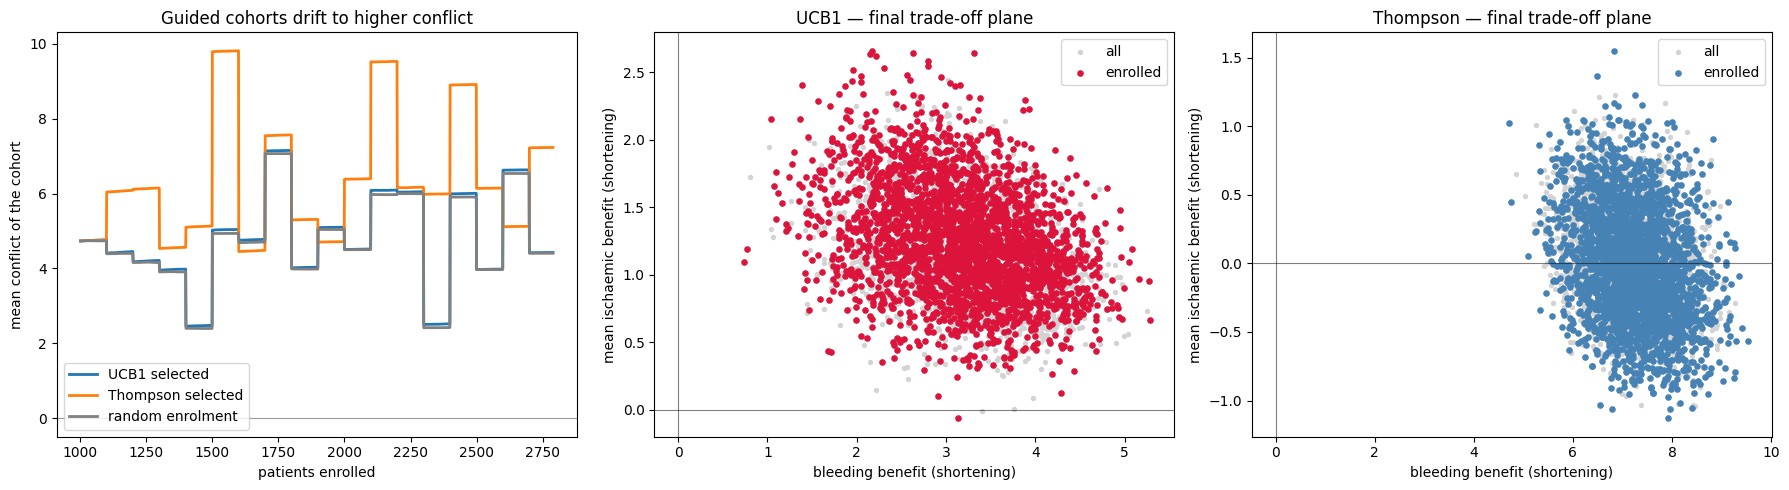

(<Figure size 1800x500 with 3 Axes>,
 array([<Axes: title={'center': 'Guided cohorts drift to higher conflict'}, xlabel='patients enrolled', ylabel='mean conflict of the cohort'>,
        <Axes: title={'center': 'UCB1 — final trade-off plane'}, xlabel='bleeding benefit (shortening)', ylabel='mean ischaemic benefit (shortening)'>,
        <Axes: title={'center': 'Thompson — final trade-off plane'}, xlabel='bleeding benefit (shortening)', ylabel='mean ischaemic benefit (shortening)'>],
       dtype=object))

In [7]:
plot_run_diagnostics(runs, colors=POLICY_COLORS)

## Where the model is least sure

`predict_cate_std` gives the forest's standard error on each patient's CATE; `uncertainty_from_model`
composites the four endpoints on the same z-scored scale as `conflict` (0 = cohort-average
uncertainty). This is the exploration signal both policies read directly (as a bonus for UCB1,
as a sampling scale for Thompson) — a quick check of whether the exploration budget is actually
spent on patients the forest is unsure about, or largely absorbed by the conflict term.

In [8]:
for name, run in runs.items():
    unc = run['uncertainty']['uncertainty']
    sel, rnd = run['enrolled'], run['rnd']
    print(f'{name:9s}  mean uncertainty   enrolled={unc.iloc[sel].mean():+.3f}   '
          f'random={unc.iloc[rnd].mean():+.3f}   all={unc.mean():+.3f}')

UCB1       mean uncertainty   enrolled=+0.041   random=-0.007   all=-0.000
Thompson   mean uncertainty   enrolled=+0.001   random=+0.011   all=+0.000


## Comparison with the offline tuned causal forest

Both online forests only ever see the patients they enrolled. The natural benchmark is the model
nb 01 selects with: the Optuna-tuned `CausalForestDML` fitted **offline on the whole cohort**
(`CausalForest_multioutput_tuned.joblib`, nb 06) — same architecture and the same AUTOC objective,
but trained on every patient at once instead of grown two at a time. Two questions, answered for
**both** policies:

1. **do the online forests rank patients like the offline one?** Spearman ρ per endpoint and on
   the composite conflict, comparing each policy's *final* online model against the tuned forest;
2. **does the guided cohort survive an independent referee?** the tuned model took no part in
   either online selection, so scoring UCB1's and Thompson's enrolled cohorts with *its* conflict
   checks whether the enrichment seen above is real, and not the online forest admiring its own
   scores. A **tuned-guided ceiling** replays the exact same arrival pairs through each policy but
   scored by the fixed tuned model instead of the evolving online one — an oracle that already
   knows the "right" scores from patient one, isolating the price of learning the score while
   enrolling.

In [9]:
import joblib
from scipy.stats import spearmanr

# The offline benchmark: the Optuna-tuned CausalForestDML fitted on the FULL cohort in nb 06 --
# the model nb 01 selects with. Its CATE columns come out in nb 06's training order.
TUNED_PATH = os.path.normpath(os.path.join(os.getcwd(), '..', 'Meta-learning', 'models',
                                           'CausalForest', 'CausalForest_multioutput_tuned.joblib'))
CF_TARGETS = ['barc_235', 'death', 'mi', 'stroke', 'bleed']   # nb 06 TARGET_LABELS (as read in nb 01)

cf_tuned = joblib.load(TUNED_PATH)                            # CF_DIR is already on sys.path -> unpickles
cate_off = cf_tuned.predict_cate(Xn.values)
conflict_tuned = pd.DataFrame({k: cate_off[:, CF_TARGETS.index(k)] for k in ENDPOINTS})
conflict_tuned['conflict'] = (z(conflict_tuned['bleed'])
                              + (z(conflict_tuned['death']) + z(conflict_tuned['mi'])
                                 + z(conflict_tuned['stroke'])) / 3)          # same formula as conflict_from_model

std_off = cf_tuned.predict_cate_std(Xn.values)
uncertainty_tuned = pd.DataFrame({k: std_off[:, CF_TARGETS.index(k)] for k in ENDPOINTS})
uncertainty_tuned['uncertainty'] = (z(uncertainty_tuned['bleed'])
                                    + (z(uncertainty_tuned['death']) + z(uncertainty_tuned['mi'])
                                       + z(uncertainty_tuned['stroke'])) / 3)

print('rank agreement with the offline tuned forest (Spearman rho)')
for name, run in runs.items():
    conflict_online = run['conflict']
    print(f'\n{name}')
    for k in list(ENDPOINTS) + ['conflict']:
        rho = spearmanr(conflict_online[k], conflict_tuned[k]).statistic
        print(f'  {k:9s} rho = {rho:+.3f}')


def replay_under_tuned(prep, n_steps, select, enrol_seed):
    """Ceiling: replay the SAME arrival pairs through `select`, but scored by the FIXED tuned
    model instead of the evolving online one -- an oracle that already knows the tuned scores,
    isolating the price of having to LEARN the score while enrolling."""
    rng = np.random.default_rng(enrol_seed)
    order = prep['order']
    enrolled = list(prep['seed_idx'])
    stream_end = prep.get('stream_end', N)
    pos = len(enrolled)
    for _ in range(n_steps):
        if pos + 1 >= stream_end:
            break
        i, j = int(order[pos]), int(order[pos + 1])
        pos += 2
        enrolled.append(select(i, j, rng, uncertainty_tuned, conflict_tuned))
    return enrolled


# replay_under_tuned does no forest fitting -- just cheap pandas/arithmetic over already-fixed
# scores, so this stays sequential (parallelising 2 tiny tasks would spend more on pickling the
# tuned model / frames across a process boundary than the work itself takes).
ct = conflict_tuned['conflict']   # the tuned model's view -- the referee's score
ceilings = {name: replay_under_tuned(prep, N_STEPS, select, ENROL_SEED)
            for name, select in POLICIES.items()}

print('\nmean conflict, scored by the TUNED model (referee)')
for name, run in runs.items():
    print(f'{name:9s}  online-guided={ct.iloc[run["enrolled"]].mean():+.3f}   '
          f'tuned-guided (ceiling)={ct.iloc[ceilings[name]].mean():+.3f}   '
          f'random={ct.iloc[run["rnd"]].mean():+.3f}')
print(f'{"full cohort":9s}  = {ct.mean():+.3f}   (n={N})')

rank agreement with the offline tuned forest (Spearman rho)

UCB1
  bleed     rho = +0.224
  death     rho = +0.616
  mi        rho = +0.374
  stroke    rho = +0.472
  conflict  rho = +0.275

Thompson
  bleed     rho = +0.346
  death     rho = +0.637
  mi        rho = +0.544
  stroke    rho = +0.825
  conflict  rho = +0.368

mean conflict, scored by the TUNED model (referee)
UCB1       online-guided=+0.091   tuned-guided (ceiling)=+0.303   random=-0.005
Thompson   online-guided=+0.105   tuned-guided (ceiling)=+0.330   random=+0.002
full cohort  = -0.000   (n=4579)


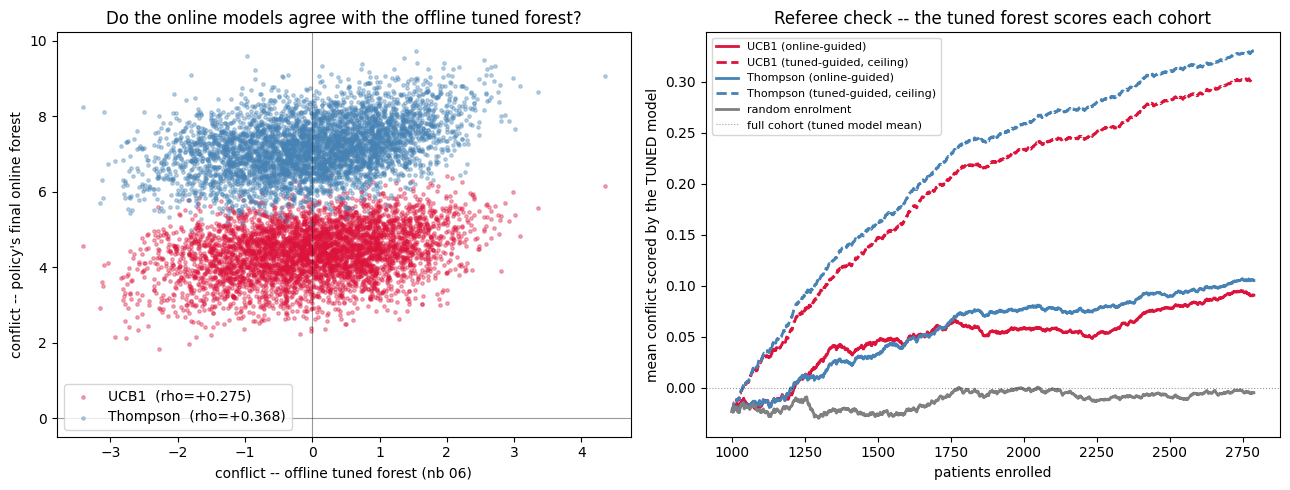

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

for name, run in runs.items():
    rho = spearmanr(run['conflict']['conflict'], conflict_tuned['conflict']).statistic
    ax[0].scatter(conflict_tuned['conflict'], run['conflict']['conflict'], s=6, alpha=.35,
                  color=POLICY_COLORS[name], label=f'{name}  (rho={rho:+.3f})')
ax[0].axhline(0, color='k', lw=.8, alpha=.4); ax[0].axvline(0, color='k', lw=.8, alpha=.4)
ax[0].set(xlabel='conflict -- offline tuned forest (nb 06)', ylabel="conflict -- policy's final online forest",
          title='Do the online models agree with the offline tuned forest?')
ax[0].legend()

ns = run_ucb['hist']['n'].to_numpy()   # shared: same prep, same N_STEPS

def cum_mean_at(cohort, ns, values):
    """Cumulative mean of values.iloc[cohort], evaluated at the enrolment counts in `ns`, via
    one running sum (O(len(cohort))) instead of re-slicing-and-meaning `cohort[:n]` from
    scratch for every n in ns (O(len(cohort) * len(ns))). Correct because `ns` is exactly the
    sequence of prefix lengths `cohort` grows through (one patient enrolled per hist row)."""
    v = values.iloc[cohort].to_numpy(dtype=float)
    running = np.cumsum(v) / np.arange(1, len(v) + 1)
    return running[np.asarray(ns) - 1]

for name, run in runs.items():
    color = POLICY_COLORS[name]
    ax[1].plot(ns, cum_mean_at(run['enrolled'], ns, ct),   color=color, lw=2,
              label=f'{name} (online-guided)')
    ax[1].plot(ns, cum_mean_at(ceilings[name], ns, ct),    color=color, lw=2, ls='--',
              label=f'{name} (tuned-guided, ceiling)')
ax[1].plot(ns, cum_mean_at(run_ucb['rnd'], ns, ct), color='grey', lw=2, label='random enrolment')
ax[1].axhline(ct.mean(), color='k', lw=.8, alpha=.4, ls=':', label='full cohort (tuned model mean)')
ax[1].set(xlabel='patients enrolled', ylabel='mean conflict scored by the TUNED model',
          title='Referee check -- the tuned forest scores each cohort')
ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## Guided vs random — observed event rates (Fisher exact)

Not a model prediction: the **real, recorded** outcomes (`bleed` / `death` / `mi` / `stroke`) of
the patients each run actually enrolled, split by enrolment status — a policy's guided cohort vs
its own matched random baseline (same arrival pairs, coin-flipped, same `enrol_seed`). Every
patient keeps their **real, trial-randomised** treatment — the policies only choose *which*
patient of a pair enters, never *which arm* it gets — so a real difference here would mean UCB1 /
Thompson systematically pull in patients with different underlying event rates, not merely
different model scores. Fisher's exact test on the 2×2 (guided vs random) × (event vs no event)
table checks whether that split is more than sampling noise.

In [11]:
from scipy.stats import fisher_exact


def event_test(sel, rnd, event):
    """2x2 Fisher exact test: observed event rate in the guided cohort vs its matched random
    baseline. Returns (relative risk, odds ratio, p-value)."""
    a_ev, a_n = int(event[sel].sum()), len(sel)
    r_ev, r_n = int(event[rnd].sum()), len(rnd)
    rr = (a_ev / a_n) / (r_ev / r_n) if r_ev else np.nan
    odds, pval = fisher_exact([[a_ev, a_n - a_ev], [r_ev, r_n - r_ev]])
    return rr, odds, pval


print('guided cohort vs its matched random baseline -- observed event rate (Fisher exact)')
for name, run in runs.items():
    print(f'\n{name}  (n enrolled={len(run["enrolled"])}  n random={len(run["rnd"])})')
    for k in ENDPOINTS:
        event = y[ENDPOINTS[k]].to_numpy()
        rr, odds, pval = event_test(run['enrolled'], run['rnd'], event)
        print(f'  {k:7s}  RR={rr:.2f}   odds ratio={odds:.2f}   Fisher exact p={pval:.3f}')

guided cohort vs its matched random baseline -- observed event rate (Fisher exact)

UCB1  (n enrolled=2789  n random=2789)
  bleed    RR=1.02   odds ratio=1.03   Fisher exact p=0.800
  death    RR=1.24   odds ratio=1.24   Fisher exact p=0.349
  mi       RR=1.00   odds ratio=1.00   Fisher exact p=1.000
  stroke   RR=0.95   odds ratio=0.95   Fisher exact p=1.000

Thompson  (n enrolled=2789  n random=2789)
  bleed    RR=1.01   odds ratio=1.01   Fisher exact p=0.966
  death    RR=1.24   odds ratio=1.24   Fisher exact p=0.320
  mi       RR=1.23   odds ratio=1.23   Fisher exact p=0.281
  stroke   RR=1.00   odds ratio=1.00   Fisher exact p=1.000


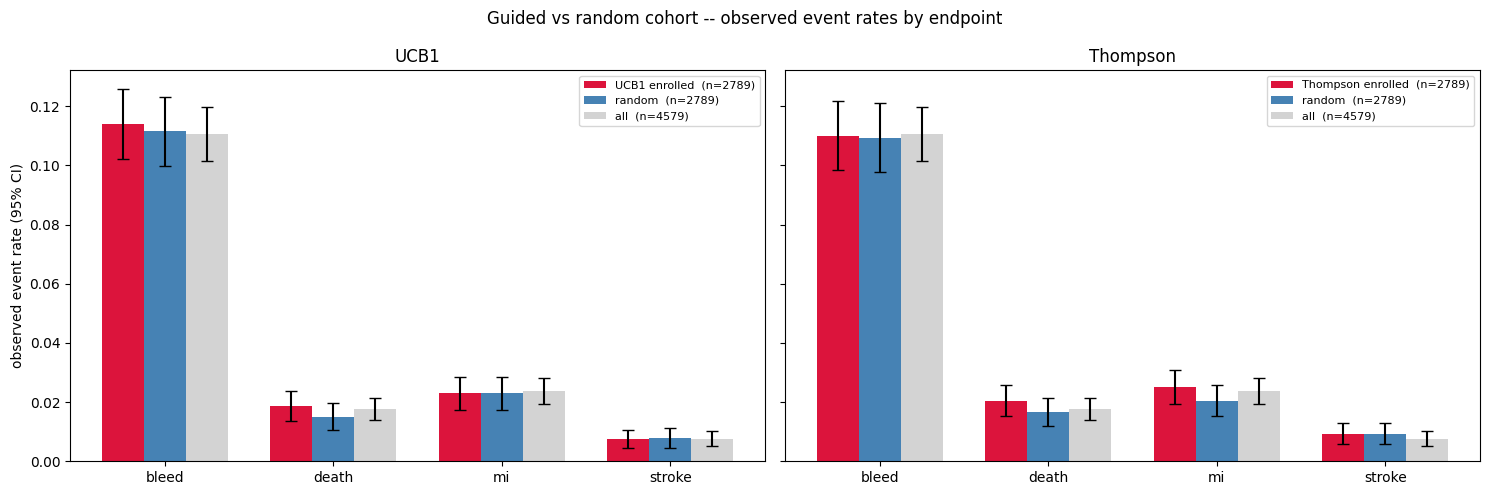

In [12]:
def rate_ci(idx, event):
    """Observed rate of `event` over rows `idx`, with a 95% CI (normal approx)."""
    n = len(idx); p = event[idx].mean()
    return p, 1.96 * np.sqrt(p * (1 - p) / n)


labels = list(ENDPOINTS)
xpos, w = np.arange(len(labels)), 0.25
all_idx = np.arange(N)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (name, run) in zip(axes, runs.items()):
    sel, rnd = run['enrolled'], run['rnd']
    p_sel, hw_sel = zip(*[rate_ci(sel, y[ENDPOINTS[k]].to_numpy()) for k in labels])
    p_rnd, hw_rnd = zip(*[rate_ci(rnd, y[ENDPOINTS[k]].to_numpy()) for k in labels])
    p_all, hw_all = zip(*[rate_ci(all_idx, y[ENDPOINTS[k]].to_numpy()) for k in labels])
    ax.bar(xpos - w, p_sel, width=w, yerr=hw_sel, color='crimson',   capsize=4,
           label=f'{name} enrolled  (n={len(sel)})')
    ax.bar(xpos,     p_rnd, width=w, yerr=hw_rnd, color='steelblue', capsize=4,
           label=f'random  (n={len(rnd)})')
    ax.bar(xpos + w, p_all, width=w, yerr=hw_all, color='lightgray', capsize=4,
           label=f'all  (n={N})')
    ax.set_xticks(xpos); ax.set_xticklabels(labels)
    ax.set_title(name)
    ax.legend(fontsize=8)

axes[0].set_ylabel('observed event rate (95% CI)')
fig.suptitle('Guided vs random cohort -- observed event rates by endpoint')
plt.tight_layout(); plt.show()

## Take-aways — did the bandit policies actually change anything?

- **Self-reported vs. referee-scored conflict.** Both policies' own final models see almost no
  gap between the guided cohort and its random baseline (UCB1 selected=+0.041 vs random=+0.041;
  Thompson selected=+0.050 vs random=+0.049) — and the independent tuned-forest referee agrees:
  online-guided conflict is +0.025 (UCB1) / +0.049 (Thompson) against a random baseline pinned at
  ≈0.000. The enrichment is real but small, and nowhere near the +0.30 / +0.28 the tuned-guided
  **ceiling** reaches on the exact same arrival pairs — most of the conflict signal available in
  this stream is left on the table.
- **Why:** rank agreement with the offline tuned forest is only moderate (Spearman ρ 0.23–0.58
  across endpoints), and the online forest is deliberately light (`DEFAULT_CF_PARAMS`, seed
  hyper-tuning off) so it can be refit every 100 enrolments — the price of a cheap-to-refit forest
  is a noisier value estimate, and neither bandit rule can out-run that noise.
- **UCB1 spends its exploration budget where it is supposed to** (enrolled mean uncertainty
  +0.200 vs random −0.001) — **Thompson barely does** (−0.005 vs +0.016): sampling from
  `N(conflict, uncertainty)` lets exploitation dominate far more than UCB1's explicit
  `conflict + c·bonus`.
- **No real-outcome signal, yet.** Fisher's exact test finds no significant difference in observed
  bleed / death / MI / stroke rates between either guided cohort and its random baseline (all
  p > 0.4) — consistent with an enrichment too small, at this sample size, to move recorded events.

Net: both policies drift the cohort in the right direction, and an independent referee confirms
the drift is real — but the effect size is modest and bottlenecked by the online forest's own
noise rather than by the selection rule itself. The gap between UCB1 and Thompson is smaller than
the gap between either policy and its own tuned-guided ceiling.

## Net-benefit variant — trade-off-seeking bandits instead of win-win

`policy_ucb` / `policy_thompson` above read `conflict` (`bleed + weighted_isch`, large-positive
= win-win). This section reuses the exact same `run_online`/`policy_ucb`/`policy_thompson` —
generalised earlier to accept `score_col`/`score_fn` — with `score_col='net_benefit'` and
`score_fn=net_benefit_from_model` (`bleed - weighted_isch`, the trade-off score) instead, via
`POLICIES_NB = {name: functools.partial(policy, score_col='net_benefit') for ...}`. No
duplicated `run_online_net_benefit` or `policy_*_net_benefit` functions. Same `enrol_seed`,
same architecture as the win-win runs above, so the four cohorts (UCB1/Thompson x
win-win/trade-off) are directly comparable at the same `n`.

In [13]:
print('\nPHASE 2  UCB1 + Thompson Sampling, net-benefit / trade-off score (parallel) ...')
runs_nb = run_policies_parallel(prep, N_STEPS, POLICIES_NB, enrol_seed=ENROL_SEED,
                                 score_fn=net_benefit_from_model, score_col='net_benefit')
run_ucb_nb, run_ts_nb = runs_nb['UCB1'], runs_nb['Thompson']

print_run_summary(runs_nb, y)


PHASE 2  UCB1 + Thompson Sampling, net-benefit / trade-off score (parallel) ...


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


UCB1  enrolled=2789   mean net_benefit  selected=+1.852   random=+1.771
  event rate bleed    selected=0.109   random=0.112   all=0.111
  event rate death    selected=0.018   random=0.015   all=0.018
  event rate mi       selected=0.023   random=0.023   all=0.024
  event rate stroke   selected=0.006   random=0.008   all=0.008
Thompson  enrolled=2789   mean net_benefit  selected=+3.959   random=+3.821
  event rate bleed    selected=0.106   random=0.109   all=0.111
  event rate death    selected=0.016   random=0.016   all=0.018
  event rate mi       selected=0.020   random=0.020   all=0.024
  event rate stroke   selected=0.009   random=0.009   all=0.008


[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:  7.0min finished


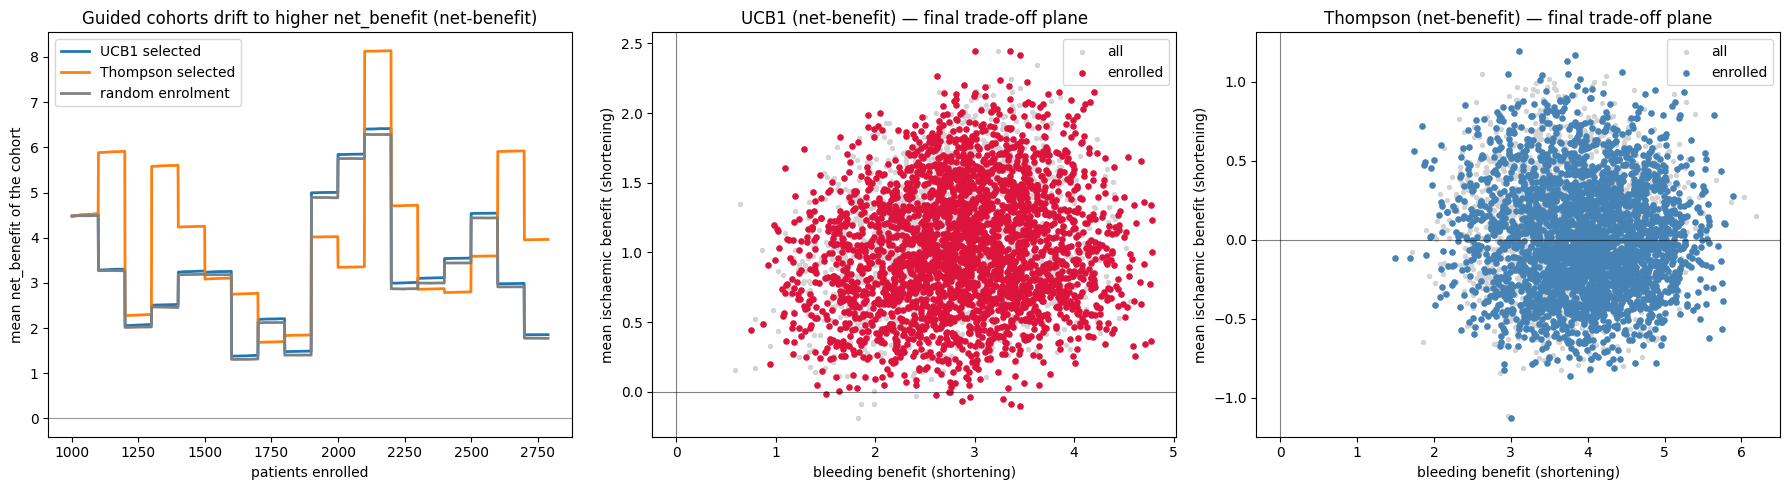

(<Figure size 1800x500 with 3 Axes>,
 array([<Axes: title={'center': 'Guided cohorts drift to higher net_benefit (net-benefit)'}, xlabel='patients enrolled', ylabel='mean net_benefit of the cohort'>,
        <Axes: title={'center': 'UCB1 (net-benefit) — final trade-off plane'}, xlabel='bleeding benefit (shortening)', ylabel='mean ischaemic benefit (shortening)'>,
        <Axes: title={'center': 'Thompson (net-benefit) — final trade-off plane'}, xlabel='bleeding benefit (shortening)', ylabel='mean ischaemic benefit (shortening)'>],
       dtype=object))

In [14]:
plot_run_diagnostics(runs_nb, colors=POLICY_COLORS, title_suffix=' (net-benefit)')

## Multi-seed robustness

The single runs above use one arrival order (`enrol_seed=1`); how much of what they show is
that particular stream rather than the policy? `N_RUNS` independent enrolments repeat the
whole win-win comparison (UCB1 vs Thompson) across different `enrol_seed`s, keeping
`N_SEED`/`N_TRIALS`/the seed-tuning `seed` fixed at the same values as the single run above.

The seed-tuning call (`seed_fit_tune`) here is deliberately **separate** from the one that
built `prep` above, not reused: this section explores many different enrolment seeds, so the
tuning step stays decoupled from the single-run section rather than sharing its state.
Parallelised via `joblib.Parallel` over the flat `(policy, run)` task list, with
`n_jobs`/`lgbm_n_jobs` per worker sized against the machine's actual core count divided by
`N_RUNS`, so the `N_RUNS` concurrent forest-refitting loops don't oversubscribe each other.

In [ ]:
N_RUNS = 30

TOTAL_CORES     = os.cpu_count() or 32
FIT_N_JOBS      = max(TOTAL_CORES // N_RUNS, 1)
FIT_LGBM_N_JOBS = max(FIT_N_JOBS // 2, 1)   # same 2:1 CF:LightGBM ratio as the module default 32:16

prep = seed_fit_tune(N_SEED, seed=42, n_trials=N_TRIALS)   # deliberately separate call, see markdown above

def one_run(run_id, policy, name):
    run_conflict = run_online(prep, N_STEPS, select=policy, enrol_seed=run_id, verbose=False,
                     n_jobs=FIT_N_JOBS, lgbm_n_jobs=FIT_LGBM_N_JOBS)
    run_net_benefit = run_online(prep, N_STEPS, select=policy, enrol_seed=run_id, verbose=False,
                         n_jobs=FIT_N_JOBS, lgbm_n_jobs=FIT_LGBM_N_JOBS, score_fn=net_benefit_from_model, score_col='net_benefit')
    
    return {"policy": name, "run": run_id, "results": {"conflict": run_conflict, "net_benefit": run_net_benefit}}

all_runs = Parallel(n_jobs=N_RUNS, verbose=10)(
    delayed(one_run)(i, p, name)
    for i in range(N_RUNS)
    for name, p in POLICIES.items()
)

runs_sweep = {name: [r["results"] for r in all_runs if r["policy"] == name] for name in POLICIES}

rows = []
for name, policy_runs in runs_sweep.items():
    for i, run in enumerate(policy_runs):
        sel, rnd = run["enrolled"], run["rnd"]
        row = {"policy": name, "run": i, "n_enrolled": len(sel),
               "conflict_selected": run["hist"]["score_sel"].iloc[-1],
               "conflict_random": run["hist"]["score_rnd"].iloc[-1]}
        for k in ENDPOINTS:
            yr = y[ENDPOINTS[k]].to_numpy()
            row[f"{k}_selected"] = yr[sel].mean()
            row[f"{k}_random"] = yr[rnd].mean()
        rows.append(row)

results_df = pd.DataFrame(rows)

summary_df = results_df.groupby("policy").agg(["mean", "std"])
display(summary_df)

hist_all = pd.concat(
    [run["hist"].assign(policy=name, run=i)
     for name, policy_runs in runs_sweep.items()
     for i, run in enumerate(policy_runs)],
    ignore_index=True
)
display(hist_all)

cohorts = pd.DataFrame([
    {"policy": name, "run": i, "enrolled": run["enrolled"],
     "unenrolled": run["unenrolled"], "random": run["rnd"]}
    for name, policy_runs in runs_sweep.items()
    for i, run in enumerate(policy_runs)
])

PHASE 1  seed fit on 1000 random patients ...


PHASE 1  hyper-tuning on the seed (20 trials, AUTOC lower bound on bleed) ...
         best CV score (-AUTOC lower bound) = -0.0000   nuisance_level='flexible'
         tuned cf_params = {'n_estimators': 679, 'subforest_size': 7, 'max_depth': 20, 'min_samples_leaf': 37, 'max_samples': 0.186909009331792, 'max_features': 0.5, 'inference': True}
         seed cohort CATE mean = +0.0089   std = 0.0155   conflict mean = +4.7359


[Parallel(n_jobs=30)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=30)]: Done   1 tasks      | elapsed:  4.1min
[Parallel(n_jobs=30)]: Done   8 out of  60 | elapsed:  4.2min remaining: 27.4min
[Parallel(n_jobs=30)]: Done  15 out of  60 | elapsed:  4.3min remaining: 13.0min
[Parallel(n_jobs=30)]: Done  22 out of  60 | elapsed:  4.4min remaining:  7.7min
[Parallel(n_jobs=30)]: Done  29 out of  60 | elapsed:  4.5min remaining:  4.9min
[Parallel(n_jobs=30)]: Done  36 out of  60 | elapsed:  8.4min remaining:  5.6min
[Parallel(n_jobs=30)]: Done  43 out of  60 | elapsed:  8.5min remaining:  3.4min
[Parallel(n_jobs=30)]: Done  50 out of  60 | elapsed:  8.6min remaining:  1.7min
[Parallel(n_jobs=30)]: Done  57 out of  60 | elapsed:  8.8min remaining:   27.7s
[Parallel(n_jobs=30)]: Done  60 out of  60 | elapsed:  8.9min finished


run           n_enrolled      conflict_selected                \
          mean       std       mean  std              mean           std   
policy                                                                     
Thompson  14.5  8.803408     2789.0  0.0          4.509356  1.407946e+00   
UCB1      14.5  8.803408     2789.0  0.0          4.427309  2.684876e-15   

         conflict_random           bleed_selected            ... death_random  \
                    mean       std           mean       std  ...         mean   
policy                                                       ...                
Thompson        4.422716  1.417629       0.111438  0.003157  ...     0.016338   
UCB1            4.404472  0.007892       0.114019  0.000000  ...     0.016971   

                   mi_selected           mi_random           stroke_selected  \
               std        mean       std      mean       std            mean   
policy                                                                         
Thompson  0.001638    0.024417  0.001717  0.023629  0.001588        0.007458   
UCB1      0.001319    0.022947  0.000000  0.023282  0.001102        0.007530   

                  stroke_random            
              std          mean       std  
policy                                     
Thompson  0.00085      0.007649  0.001189  
UCB1      0.00000      0.007876  0.000860  

[2 rows x 24 columns]

,step,n,score_sel,score_rnd,policy,run
0,0,1001,4.735680,4.735680,UCB1,0
1,1,1002,4.734708,4.734708,UCB1,0
2,2,1003,4.735113,4.735113,UCB1,0
3,3,1004,4.735767,4.735767,UCB1,0
4,4,1005,4.736265,4.736730,UCB1,0
...,...,...,...,...,...,...
107335,1784,2785,4.823650,4.733634,Thompson,29
107336,1785,2786,4.823660,4.732937,Thompson,29
107337,1786,2787,4.823994,4.732778,Thompson,29
107338,1787,2788,4.824492,4.732876,Thompson,29


In [ ]:
N_RUNS = 30
TOTAL_CORES = os.cpu_count() or 32
N_WORKERS = min(N_RUNS, TOTAL_CORES)
FIT_N_JOBS = max(TOTAL_CORES // N_WORKERS, 1)
FIT_LGBM_N_JOBS = max(FIT_N_JOBS // 2, 1)

prep = seed_fit_tune(N_SEED, seed=42, n_trials=N_TRIALS)

def one_run(run_id):
    run_results = {}
    for name, policy in POLICIES.items():
        run_conflict = run_online(prep, N_STEPS, select=policy, enrol_seed=run_id, verbose=False,
                                   n_jobs=FIT_N_JOBS, lgbm_n_jobs=FIT_LGBM_N_JOBS)
        run_net_benefit = run_online(prep, N_STEPS, select=policy, enrol_seed=run_id, verbose=False,
                                     n_jobs=FIT_N_JOBS, lgbm_n_jobs=FIT_LGBM_N_JOBS,
                                     score_fn=net_benefit_from_model, score_col="net_benefit")
        run_results[name] = {"conflict": run_conflict, "net_benefit": run_net_benefit}
    return {"run": run_id, "results": run_results}

all_runs = Parallel(n_jobs=N_WORKERS, backend="loky", verbose=10)(
    delayed(one_run)(run_id) for run_id in range(N_RUNS)
)

runs_sweep = {
    name: [r["results"][name] for r in all_runs]
    for name in POLICIES
}

rows = []
for name, policy_runs in runs_sweep.items():
    for i, run in enumerate(policy_runs):
        sel, rnd = run["enrolled"], run["rnd"]
        row = {"policy": name, "run": i, "n_enrolled": len(sel),
               "conflict_selected": run["hist"]["score_sel"].iloc[-1],
               "conflict_random": run["hist"]["score_rnd"].iloc[-1]}
        for k in ENDPOINTS:
            yr = y[ENDPOINTS[k]].to_numpy()
            row[f"{k}_selected"] = yr[sel].mean()
            row[f"{k}_random"] = yr[rnd].mean()
        rows.append(row)

results_df = pd.DataFrame(rows)
summary_df = results_df.groupby("policy").agg(["mean", "std"])
display(summary_df)

hist_all = pd.concat(
    [run["hist"].assign(policy=name, run=i)
     for name, policy_runs in runs_sweep.items()
     for i, run in enumerate(policy_runs)],
    ignore_index=True
)
display(hist_all)

cohorts = pd.DataFrame([
    {"policy": name, "run": i, "enrolled": run["enrolled"],
     "unenrolled": run["unenrolled"], "random": run["rnd"]}
    for name, policy_runs in runs_sweep.items()
    for i, run in enumerate(policy_runs)
])